<a href="https://colab.research.google.com/github/rounak393/clab/blob/main/Unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import PIL

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

class MaskTransform:
    def __call__(self, target):
        target = target.resize((128, 128), PIL.Image.NEAREST)
        target = torch.as_tensor(np.array(target), dtype=torch.long)
        return target - 1

print("Downloading dataset...")
dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=transform,
    target_transform=MaskTransform()
)

small_dataset = Subset(dataset, range(200))
train_loader = DataLoader(small_dataset, batch_size=8, shuffle=True)

print(f"Loaded {len(small_dataset)} images.")

100%|██████████| 792M/792M [00:30<00:00, 25.7MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.0MB/s]


Loaded 200 images.


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        self.up1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv1 = DoubleConv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv2 = DoubleConv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv3 = DoubleConv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv4 = DoubleConv(128, 64)

        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5)
        x = self.conv1(torch.cat([x4, x], dim=1))

        x = self.up2(x)
        x = self.conv2(torch.cat([x3, x], dim=1))

        x = self.up3(x)
        x = self.conv3(torch.cat([x2, x], dim=1))

        x = self.up4(x)
        x = self.conv4(torch.cat([x1, x], dim=1))

        return self.outc(x)

In [ ]:
model = UNet(n_channels=3, n_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 10

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()

        preds = model(images)
        loss = criterion(preds, masks)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

Epoch 1/10 | Loss: 0.5971
Epoch 2/10 | Loss: 0.5761
Epoch 3/10 | Loss: 0.5578
Epoch 4/10 | Loss: 0.5580
Epoch 5/10 | Loss: 0.5259
Epoch 6/10 | Loss: 0.5047
Epoch 7/10 | Loss: 0.5144
Epoch 8/10 | Loss: 0.4718
Epoch 9/10 | Loss: 0.4594
Epoch 10/10 | Loss: 0.4560


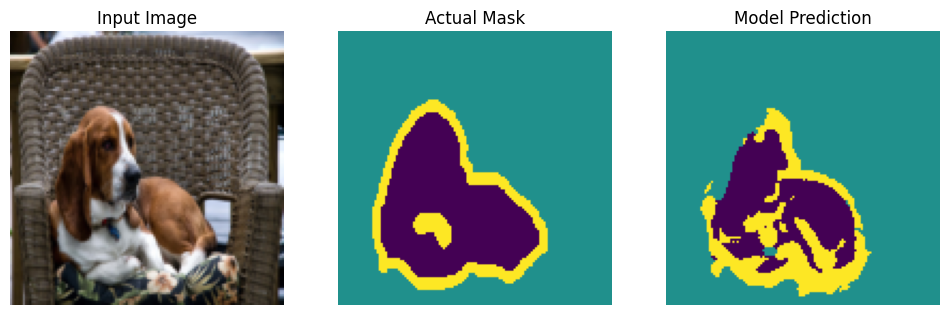

In [ ]:
model.eval()

with torch.no_grad():
    images, masks = next(iter(train_loader))
    images, masks = images.to(device), masks.to(device)

    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    img = images[0].cpu().permute(1, 2, 0).numpy()
    true_mask = masks[0].cpu().numpy()
    pred_mask = preds[0].cpu().numpy()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.imshow(img)
ax1.set_title("Input Image")
ax1.axis("off")

ax2.imshow(true_mask)
ax2.set_title("Actual Mask")
ax2.axis("off")

ax3.imshow(pred_mask)
ax3.set_title("Model Prediction")
ax3.axis("off")

plt.show()

In [ ]:
def calculate_iou(preds, labels, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = labels == cls

        intersection = (pred_inds[target_inds]).long().sum().item()
        union = pred_inds.long().sum().item() + target_inds.long().sum().item() - intersection

        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(float(intersection) / float(max(union, 1)))

    valid_ious = [iou for iou in ious if not np.isnan(iou)]
    return np.mean(valid_ious)

model.eval()
total_iou = 0.0
batches = 0

with torch.no_grad():
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        batch_iou = calculate_iou(preds, masks, num_classes=3)
        total_iou += batch_iou
        batches += 1

miou_score = total_iou / batches
print(f"Mean Intersection over Union (mIoU): {miou_score:.4f}")

Mean Intersection over Union (mIoU): 0.5589
